### 📚 Merging All Climate Trends for Machine Learning

This notebook brings together all key environmental and climate trend datasets—temperature, rainfall, bushfire area, aridity, NDVI, sea surface temperature, and more—into a single, unified dataframe.

- Each row represents one year.
- Each column is a different climate variable.
- This combined dataset forms the basis for all subsequent machine learning analysis and future predictions.

> By merging these trends, we enable robust forecasting and habitability risk assessment for Australia’s next century.


In [15]:
import pandas as pd
import os

# No rainfall, NDVI and Aridity because they are included in desertificationRate
DESERTIFICATION_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data\desertificationRate"

TEMP_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data\temp"
HEATDAYS_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data\heatDays"
BUSHFIRES_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data\bushfires"
FLOODS_AND_CYCLONES_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data\floods&cyclones"
UHI_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data\urbanHeatIsland"
SST_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data\seaSurfaceTemperature"



In [16]:
# Loading each main dataset
desertification_df = pd.read_csv(os.path.join(DESERTIFICATION_DIR, "australia_desertification_indicators.csv"))
# Rainfall, NDVI and Aridity are included in desertification_df
temp_df = pd.read_csv(os.path.join(TEMP_DIR, "aus_mean_temp.csv"))
heatdays_df = pd.read_csv(os.path.join(HEATDAYS_DIR, "National_Hot_Days__35_C__Simulated_1986_2022_.csv"))
bushfires_df = pd.read_csv(os.path.join(BUSHFIRES_DIR, "Bushfire_Burned_Area__2001_2022_.csv"))                                 
flood_and_cyclones_df = pd.read_csv(os.path.join(FLOODS_AND_CYCLONES_DIR, "Flood_Cyclones_Events.csv"))                           
uhi_df = pd.read_csv(os.path.join(UHI_DIR, "urban_heat_island_annual_summary.csv"))   
sst_df = pd.read_csv(os.path.join(SST_DIR, "SST_absolute_1991_2024.csv")) 

print(temp_df)
print(desertification_df)
print(heatdays_df)
print(bushfires_df)
print(flood_and_cyclones_df)
print(uhi_df)
print(sst_df)
                                 

       Decade  Mean_Temperature
0   1911-1920         21.218677
1   1921-1930         21.150766
2   1931-1940         21.200029
3   1941-1950         21.075919
4   1951-1960         21.196777
5   1961-1970         21.287564
6   1971-1980         21.398203
7   1981-1990         21.582206
8   1991-2000         21.620416
9   2001-2010         21.858513
10  2011-2020         22.165803
    Year  Rainfall (mm)  Rainfall Anomaly (mm)  Aridity Index (P/PET)  \
0   1982         415.14                 -50.90               0.283600   
1   1983         492.99                  26.95               0.336783   
2   1984         546.45                  80.42               0.373304   
3   1985         397.53                 -68.50               0.271570   
4   1986         385.94                 -80.10               0.263653   
5   1987         450.08                 -15.95               0.307469   
6   1988         454.26                 -11.77               0.310325   
7   1989         480.30         

In [20]:
# temp_df has a problem with "Year", it's decadal not annual
temp_df = pd.read_csv(os.path.join(TEMP_DIR, "aus_mean_temp.csv"))

annual_rows = []
for idx, row in temp_df.iterrows():
    decade_str = row["Decade"]
    start_year, end_year = [int(x) for x in decade_str.split("-")]
    for y in range(start_year, end_year + 1):
        annual_rows.append({
            "Year": y,
            "Mean_Temperature": row["Mean_Temperature"]
        })

# Filling temp_df with annual data
temp_df = pd.DataFrame(annual_rows)

print(temp_df.head())
print(temp_df.tail())

   Year  Mean_Temperature
0  1911         21.218677
1  1912         21.218677
2  1913         21.218677
3  1914         21.218677
4  1915         21.218677
     Year  Mean_Temperature
105  2016         22.165803
106  2017         22.165803
107  2018         22.165803
108  2019         22.165803
109  2020         22.165803


In [29]:
print(temp_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              110 non-null    int64  
 1   Mean_Temperature  110 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.8 KB
None


In [30]:
print(desertification_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   41 non-null     int64  
 1   Rainfall (mm)          41 non-null     float64
 2   Rainfall Anomaly (mm)  41 non-null     float64
 3   Aridity Index (P/PET)  41 non-null     float64
 4   Mean_NDVI              41 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.7 KB
None


In [ ]:
print(heatdays_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 2 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year                              37 non-null     int64  
 1   Estimated_National_Hot_Days_>35C  37 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 724.0 bytes
None


,Year,Estimated_National_Hot_Days_>35C
0,1986,70.6
1,1987,69.3
2,1988,70.9
3,1989,72.6
4,1990,69.1
5,1991,69.1
6,1992,72.8
7,1993,71.1
8,1994,68.7
9,1995,70.7


In [32]:
print(bushfires_df.info())
print(flood_and_cyclones_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             22 non-null     int64  
 1   Burned_Area_Mha  22 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 484.0 bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         22 non-null     int64
 1   Year               22 non-null     int64
 2   Major_Flood_Event  22 non-null     int64
 3   Cyclone_Landfalls  22 non-null     int64
dtypes: int64(4)
memory usage: 836.0 bytes
None


In [40]:
if "Unnamed: 0" in flood_and_cyclones_df.columns:
    flood_and_cyclones_df = flood_and_cyclones_df.drop(columns=["Unnamed: 0"], axis=1)
flood_and_cyclones_df

,Year,Major_Flood_Event,Cyclone_Landfalls
0,2001,0,5
1,2002,1,4
2,2003,0,6
3,2004,0,4
4,2005,1,3
5,2006,0,2
6,2007,0,6
7,2008,1,5
8,2009,0,4
9,2010,0,3


In [42]:
print(sst_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          125 non-null    int64  
 1   SST_Anomaly   125 non-null    float64
 2   Absolute_SST  125 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 3.1 KB
None


In [44]:
# For a National analisis, I'm going to ignore Urban Heat Island dataframe (city level)

# Final Dataframe will be 2001-2022, years with missing data will be dropped
dataframes = [temp_df, desertification_df, heatdays_df, bushfires_df, flood_and_cyclones_df, sst_df]

# Merging all dataframes on "Year"
from functools import reduce
merged_df = reduce(lambda left, right: pd.merge(left, right, on="Year", how="inner"), dataframes)

print(merged_df["Year"].min(), merged_df["Year"].max()) # Shared year range
print(merged_df.shape)
print(merged_df.info())


2001 2020
(20, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year                              20 non-null     int64  
 1   Mean_Temperature                  20 non-null     float64
 2   Rainfall (mm)                     20 non-null     float64
 3   Rainfall Anomaly (mm)             20 non-null     float64
 4   Aridity Index (P/PET)             20 non-null     float64
 5   Mean_NDVI                         20 non-null     float64
 6   Estimated_National_Hot_Days_>35C  20 non-null     float64
 7   Burned_Area_Mha                   20 non-null     float64
 8   Major_Flood_Event                 20 non-null     int64  
 9   Cyclone_Landfalls                 20 non-null     int64  
 10  SST_Anomaly                       20 non-null     float64
 11  Absolute_SST                      20 non-null     floa

In [49]:
print(merged_df.isnull().sum())
print(merged_df.dtypes)

Year                                0
Mean_Temperature                    0
Rainfall (mm)                       0
Rainfall Anomaly (mm)               0
Aridity Index (P/PET)               0
Mean_NDVI                           0
Estimated_National_Hot_Days_>35C    0
Burned_Area_Mha                     0
Major_Flood_Event                   0
Cyclone_Landfalls                   0
SST_Anomaly                         0
Absolute_SST                        0
dtype: int64
Year                                  int64
Mean_Temperature                    float64
Rainfall (mm)                       float64
Rainfall Anomaly (mm)               float64
Aridity Index (P/PET)               float64
Mean_NDVI                           float64
Estimated_National_Hot_Days_>35C    float64
Burned_Area_Mha                     float64
Major_Flood_Event                     int64
Cyclone_Landfalls                     int64
SST_Anomaly                         float64
Absolute_SST                        float64
dty

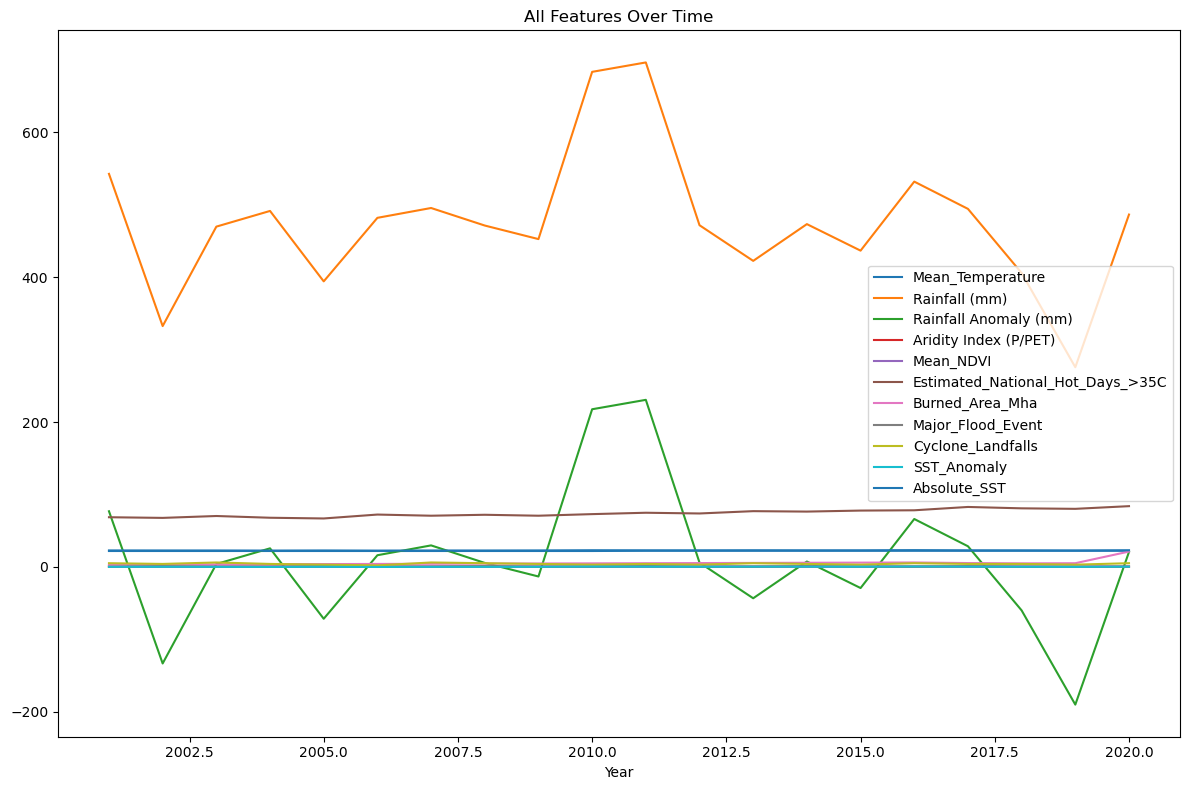

In [52]:
# Overview for numeric correlations

numeric_cols = merged_df.select_dtypes(include=["float64", "int64"])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for col in numeric_cols.columns:
    if col != "Year":
        plt.plot(merged_df["Year"], merged_df[col], label=col)
plt.legend()
plt.title("All Features Over Time")
plt.xlabel("Year")
plt.tight_layout()
plt.show()


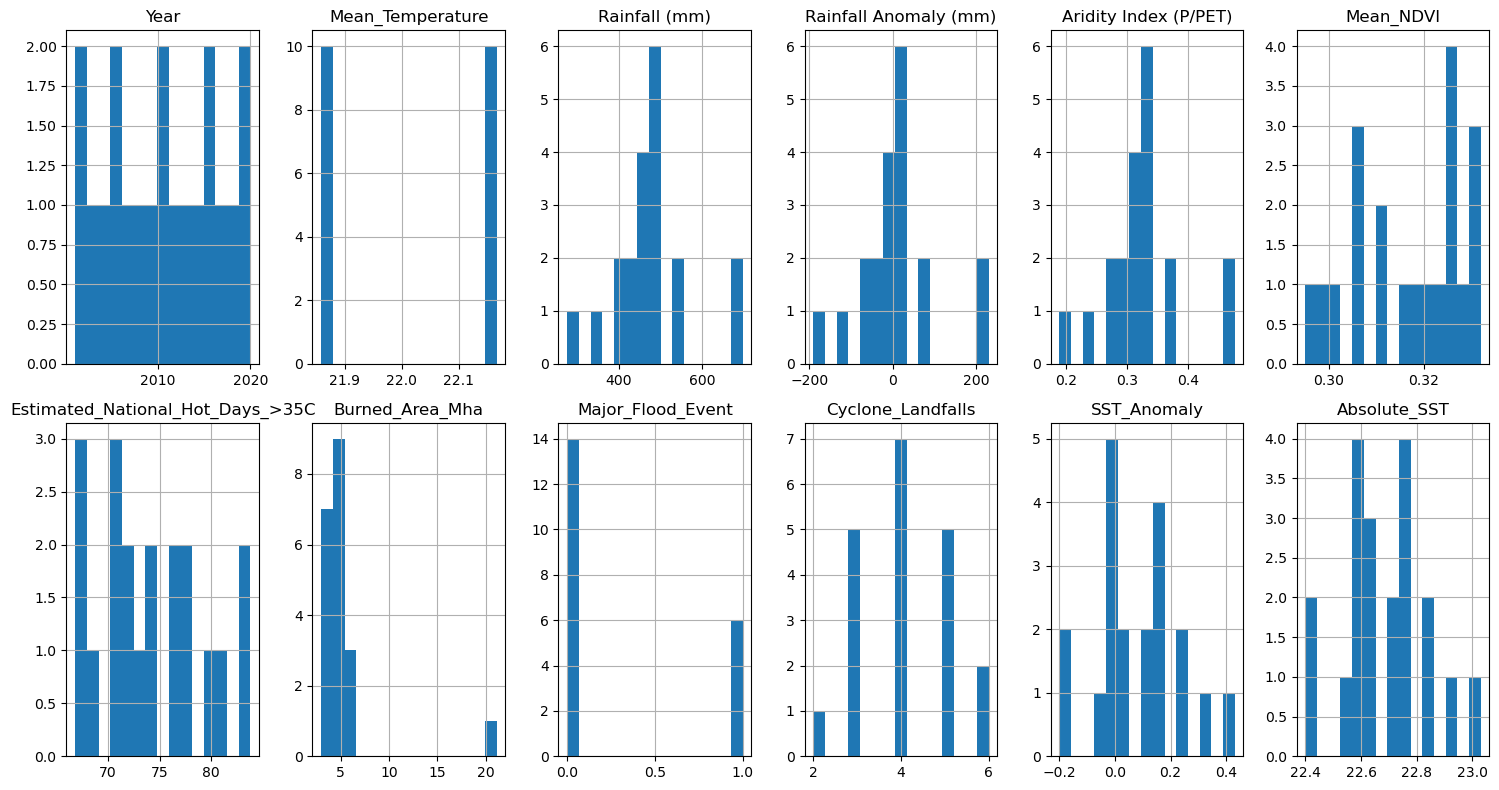

In [53]:
numeric_cols.hist(bins=15, figsize=(15, 8), layout=(2, int(len(numeric_cols.columns)/2)))
plt.tight_layout()
plt.show()

#### EDA Reflection

Comprehensive EDA steps (correlations, missing data checks) are essential.  
However, multi-feature overlaid plots and global histograms are often less informative for environmental ML—focus on individual trends, pairwise relationships, and threshold analysis for the strongest insights.
